In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("movies.csv")

In [3]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   str    
 1   rating    7591 non-null   str    
 2   genre     7668 non-null   str    
 3   year      7668 non-null   int64  
 4   released  7666 non-null   str    
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   str    
 8   writer    7665 non-null   str    
 9   star      7667 non-null   str    
 10  country   7665 non-null   str    
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   str    
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), str(9)
memory usage: 898.7 KB


In [5]:
df.isna().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

In [7]:
# Dropping the rows with null values of score, votes, writer, country, runtime
df.dropna(subset=["score", "votes", "writer", "country", "runtime"], inplace=True)

In [8]:
df["rating"]

0               R
1               R
2              PG
3              PG
4               R
          ...    
7659    Not Rated
7660          NaN
7663          NaN
7664          NaN
7667          NaN
Name: rating, Length: 7657, dtype: str

In [9]:
df["rating"].value_counts()

rating
R            3694
PG-13        2111
PG           1252
Not Rated     282
G             153
Unrated        51
NC-17          23
TV-MA           9
TV-PG           4
X               3
Approved        1
TV-14           1
Name: count, dtype: int64

In [12]:
# Filling the missing values of ratings with the mode
mode_value = df["rating"].mode()[0]
df["rating"] = df["rating"].fillna(mode_value)

In [13]:
df.isna().sum()

name           0
rating         0
genre          0
year           0
released       0
score          0
votes          0
director       0
writer         0
star           1
country        0
budget      2166
gross        183
company       13
runtime        0
dtype: int64

In [19]:
# Now filling the missing values in the dataset for budget
# First checking the distribution of the data
print(df["budget"].skew())

2.452858857952904


<Axes: xlabel='budget', ylabel='Count'>

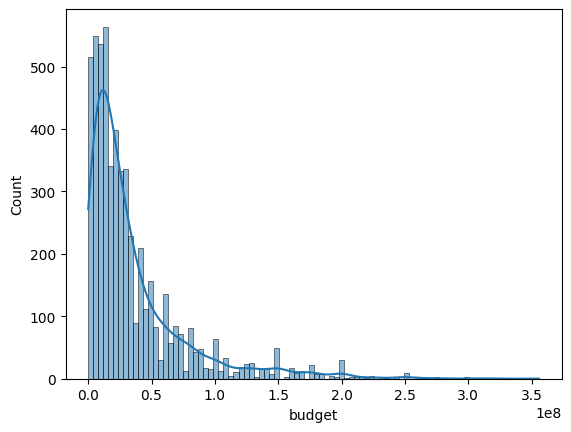

In [20]:
sns.histplot(df["budget"].dropna(), kde=True)

In [21]:
# As the graph and the skew function suggest the data in the budget column so we will use median to fill it
df["budget"] = df["budget"].fillna(df["budget"].median())

5.37932959341367


<Axes: xlabel='gross', ylabel='Count'>

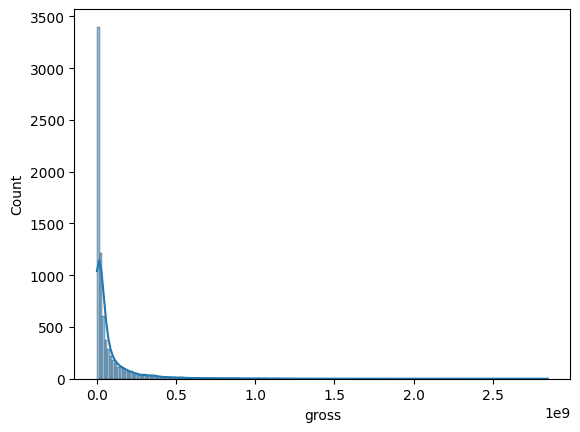

In [27]:
print(df["gross"].skew())
sns.histplot(df["gross"].dropna(), kde=True)

In [33]:
# Same case here that it is highly skewed data
# So now filling the gross with the median
df["gross"] = df["gross"].fillna(df["gross"].median())
# For the text data like company we cannot fill it with any data from our side as it is not a rule that which company might have produced this content
# So to handle these null values I will fill it with UNKNWON
# I cannot leave these values as it is as if I do so they will not be used during plotting or groupby. I don't want to loose data so I will not delete them as well.
df["company"] = df["company"].fillna("UNKNOWN")

In [34]:
df.isna().sum()

name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        1
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

In [35]:
df["star"]

0         Jack Nicholson
1         Brooke Shields
2            Mark Hamill
3            Robert Hays
4            Chevy Chase
              ...       
7659      Kristina Klebe
7660         Augie Tulba
7663        Shannon Bond
7664    Michael Saquella
7667    Siyabonga Mabaso
Name: star, Length: 7657, dtype: str

In [38]:
df.duplicated().sum()

np.int64(0)

In [47]:
# As only 1 row is missing so we can drop it
df = df.dropna(subset=["star"])

In [50]:
df.isna().sum()

name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

In [51]:
df["profit"] = df["gross"]-df["budget"]

In [61]:
# As votes cannot be a float so I will convert them to integers to save memory
df["votes"] = df["votes"].astype("int")
df["runtime"] = df["runtime"].astype("int")

In [62]:
df.dtypes

name            str
rating          str
genre           str
year          int64
released        str
score       float64
votes         int64
director        str
writer          str
star            str
country         str
budget      float64
gross       float64
company         str
runtime       int64
profit      float64
dtype: object